In [6]:
import os

os.makedirs('/content/dataset', exist_ok=True)

In [7]:
url = "https://data.mendeley.com/public-files/datasets/kbb46m8j9k/files/2c398a13-8996-486f-8b47-dff89072cd2e/file_downloaded"

!wget -O /content/dataset/dataset.zip "$url"

--2026-08-18 18:01:53--  https://data.mendeley.com/public-files/datasets/kbb46m8j9k/files/2c398a13-8996-486f-8b47-dff89072cd2e/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/f8934d12-83d9-46c5-8356-037de0e52d54 [following]
--2026-08-18 18:01:54--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/f8934d12-83d9-46c5-8356-037de0e52d54
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.75.22, 52.92.35.162, 3.5.71.64, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.75.22|:443... conne

In [8]:
import os

print(os.path.exists('/content/dataset/dataset.zip'))

if os.path.exists('/content/dataset/dataset.zip'):
    print("File size:", os.path.getsize('/content/dataset/dataset.zip') / (1024**2), "MB")

True
File size: 3431.7781200408936 MB


In [9]:
!file /content/dataset/dataset.zip

/content/dataset/dataset.zip: Zip archive data, at least v1.0 to extract, compression method=store


In [10]:
import os

print(os.listdir('/content/dataset'))

['dataset.zip']


In [12]:
import zipfile
import os

zip_path = '/content/dataset/dataset.zip'
extract_path = '/content/dataset/extracted'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [13]:
os.listdir('/content/dataset/extracted')

['envelope.py',
 'parameters.pdf',
 '19',
 'load_example.py',
 '9',
 '3',
 '18',
 '16',
 '7',
 '12',
 '10',
 '5',
 'readme.pdf',
 '8',
 '20',
 '11',
 '14',
 '4',
 '2',
 '17',
 '1',
 '13',
 'data_availability.csv',
 '6']

In [14]:
for root, dirs, files in os.walk('/content/dataset/extracted'):
    level = root.replace('/content/dataset/extracted', '').count(os.sep)
    indent = '  ' * level

    print(indent + os.path.basename(root) + '/')

    for file in files[:5]:
        print(indent + '  ' + file)

    if level > 3:
        dirs[:] = []

extracted/
  envelope.py
  parameters.pdf
  load_example.py
  readme.pdf
  data_availability.csv
  19/
    IMU/
      b_MT_00130934_008-000_quat.csv
      r_MT_00130934_008-002_quat.csv
      g_MT_00130934_008-001_quat.csv
      t_MT_00130934_008-003_quat.csv
    EMG/
      r_3_EMG_521_0420_00129_1kHz.csv
      r_3 2869340 ms 573986 data  live.csv
      b_1 2869340 ms 573937 data  live.csv
      g_4 2869340 ms 573927 data  live.csv
      t_2_EMG_521_0420_00130_1kHz.csv
    ExerciseQuality/
      Plank walkout.csv
      Lunge (right leg forward).csv
      Burpees.csv
      Forearm plank hold.csv
      Triceps push-ups.csv
    HR/
      19397013741_ACTIVITY-record.csv
    Segmented/
      Repetitive/
        Burpees.csv
        High knee run.csv
        Push-ups.csv
        Standard squat.csv
        Jump squats.csv
      NonRepetitive/
        Plank walkout.csv
        Biceps.csv
        Jumping jacks.csv
        Arm rotations.csv
        Hip rotation.csv
  9/
    IMU/
      t_MT_001309

In [15]:
import glob

csv_files = glob.glob(
    '/content/dataset/extracted/**/*.csv',
    recursive=True
)

print("Total CSV files:", len(csv_files))

for f in csv_files[:30]:
    print(f)

Total CSV files: 1476
/content/dataset/extracted/data_availability.csv
/content/dataset/extracted/19/IMU/b_MT_00130934_008-000_quat.csv
/content/dataset/extracted/19/IMU/r_MT_00130934_008-002_quat.csv
/content/dataset/extracted/19/IMU/g_MT_00130934_008-001_quat.csv
/content/dataset/extracted/19/IMU/t_MT_00130934_008-003_quat.csv
/content/dataset/extracted/19/EMG/r_3_EMG_521_0420_00129_1kHz.csv
/content/dataset/extracted/19/EMG/r_3 2869340 ms 573986 data  live.csv
/content/dataset/extracted/19/EMG/b_1 2869340 ms 573937 data  live.csv
/content/dataset/extracted/19/EMG/g_4 2869340 ms 573927 data  live.csv
/content/dataset/extracted/19/EMG/t_2_EMG_521_0420_00130_1kHz.csv
/content/dataset/extracted/19/EMG/g_4_EMG_521_0420_00124_1kHz.csv
/content/dataset/extracted/19/EMG/b_1_EMG_521_0420_00133_1kHz.csv
/content/dataset/extracted/19/EMG/t_2 2869340 ms 573961 data  live.csv
/content/dataset/extracted/19/ExerciseQuality/Plank walkout.csv
/content/dataset/extracted/19/ExerciseQuality/Lunge (righ

In [16]:
import pandas as pd
import os

base_path = '/content/dataset/extracted'

file_path = os.path.join(
    base_path,
    '1',
    'Segmented',
    'Repetitive',
    'Burpees.csv'
)

df = pd.read_csv(file_path)

print("File:", file_path)
print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, "->", col)

print("\nFirst 5 rows:")
display(df.head())

File: /content/dataset/extracted/1/Segmented/Repetitive/Burpees.csv
Shape: (4928, 26)

Columns:
0 -> Sample
1 -> Biceps_EMG
2 -> Biceps_EMG_Envelope
3 -> Biceps_Q1
4 -> Biceps_Q2
5 -> Biceps_Q3
6 -> Biceps_Q4
7 -> Triceps_EMG
8 -> Triceps_EMG_Envelope
9 -> Triceps_Q1
10 -> Triceps_Q2
11 -> Triceps_Q3
12 -> Triceps_Q4
13 -> Gastrocnemious_EMG
14 -> Gastrocnemious_EMG_Envelope
15 -> Gastrocnemious_Q1
16 -> Gastrocnemious_Q2
17 -> Gastrocnemious_Q3
18 -> Gastrocnemious_Q4
19 -> Rectus_EMG
20 -> Rectus_EMG_Envelope
21 -> Rectus_Q1
22 -> Rectus_Q2
23 -> Rectus_Q3
24 -> Rectus_Q4
25 -> Exercise_Phase

First 5 rows:


,Sample,Biceps_EMG,Biceps_EMG_Envelope,Biceps_Q1,Biceps_Q2,Biceps_Q3,Biceps_Q4,Triceps_EMG,Triceps_EMG_Envelope,Triceps_Q1,...,Gastrocnemious_Q2,Gastrocnemious_Q3,Gastrocnemious_Q4,Rectus_EMG,Rectus_EMG_Envelope,Rectus_Q1,Rectus_Q2,Rectus_Q3,Rectus_Q4,Exercise_Phase
0,1397.610,-6.707810,6.674671,-0.558975,-0.455288,0.593859,0.357200,71.483487,118.128675,-0.321491,...,0.013132,0.288340,0.082681,3885.966835,1305.856304,-0.234968,0.282324,0.138144,-0.919782,0.000000
1,1397.615,-8.328125,8.455829,-0.558975,-0.455288,0.593859,0.357200,-21.056712,117.551826,-0.321491,...,0.013132,0.288340,0.082681,6547.583503,1336.066637,-0.234968,0.282324,0.138144,-0.919782,0.097943
2,1397.620,-13.777605,11.932922,-0.562568,-0.450605,0.596106,0.353737,-162.930342,118.209386,-0.321029,...,0.014564,0.286287,0.093647,8173.025744,1366.245549,-0.243155,0.296139,0.159715,-0.909763,0.195886
3,1397.625,-11.179683,17.638878,-0.562568,-0.450605,0.596106,0.353737,-95.349894,118.826021,-0.321029,...,0.014564,0.286287,0.093647,8900.677846,1410.655157,-0.243155,0.296139,0.159715,-0.909763,0.293830
4,1397.630,-1.807464,23.947546,-0.565396,-0.445821,0.599005,0.350376,22.115581,118.240013,-0.320549,...,0.014233,0.284107,0.103057,9040.667674,1473.716441,-0.248054,0.304114,0.174849,-0.903001,0.391773


In [17]:
quality_path = os.path.join(
    base_path,
    '1',
    'ExerciseQuality',
    'Burpees.csv'
)

quality_df = pd.read_csv(quality_path)

print("File:", quality_path)
print("Shape:", quality_df.shape)

print("\nColumns:")
for i, col in enumerate(quality_df.columns):
    print(i, "->", col)

print("\nFirst rows:")
display(quality_df.head())

File: /content/dataset/extracted/1/ExerciseQuality/Burpees.csv
Shape: (1, 12)

Columns:
0 -> jump_height
1 -> transition_to_squat_I
2 -> squat_depth
3 -> transition_to_plank_I
4 -> plank_position
5 -> body_down_to_floor
6 -> transition_to_plank_II
7 -> transition_to_squat_II
8 -> movement_fluidity
9 -> technique
10 -> hold_and_tempo
11 -> overall quality

First rows:


,jump_height,transition_to_squat_I,squat_depth,transition_to_plank_I,plank_position,body_down_to_floor,transition_to_plank_II,transition_to_squat_II,movement_fluidity,technique,hold_and_tempo,overall quality
0,1,1,0,1,0,0,0,1,0,1,1,4


In [18]:
print("=== REPETITIVE DATA ===")
print(df.info())

print("\nMissing values:")
display(df.isna().sum())

print("\n\n=== QUALITY DATA ===")
print(quality_df.info())

print("\nMissing values:")
display(quality_df.isna().sum())


=== REPETITIVE DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4928 entries, 0 to 4927
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample                       4928 non-null   float64
 1   Biceps_EMG                   4928 non-null   float64
 2   Biceps_EMG_Envelope          4928 non-null   float64
 3   Biceps_Q1                    4928 non-null   float64
 4   Biceps_Q2                    4928 non-null   float64
 5   Biceps_Q3                    4928 non-null   float64
 6   Biceps_Q4                    4928 non-null   float64
 7   Triceps_EMG                  4928 non-null   float64
 8   Triceps_EMG_Envelope         4928 non-null   float64
 9   Triceps_Q1                   4928 non-null   float64
 10  Triceps_Q2                   4928 non-null   float64
 11  Triceps_Q3                   4928 non-null   float64
 12  Triceps_Q4                   4928 non-null   float64

,0
Sample,0
Biceps_EMG,0
Biceps_EMG_Envelope,0
Biceps_Q1,0
Biceps_Q2,0
Biceps_Q3,0
Biceps_Q4,0
Triceps_EMG,0
Triceps_EMG_Envelope,0
Triceps_Q1,0




=== QUALITY DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   jump_height             1 non-null      int64
 1   transition_to_squat_I   1 non-null      int64
 2   squat_depth             1 non-null      int64
 3   transition_to_plank_I   1 non-null      int64
 4   plank_position          1 non-null      int64
 5   body_down_to_floor      1 non-null      int64
 6   transition_to_plank_II  1 non-null      int64
 7   transition_to_squat_II  1 non-null      int64
 8   movement_fluidity       1 non-null      int64
 9   technique               1 non-null      int64
 10  hold_and_tempo          1 non-null      int64
 11  overall quality         1 non-null      int64
dtypes: int64(12)
memory usage: 228.0 bytes
None

Missing values:


,0
jump_height,0
transition_to_squat_I,0
squat_depth,0
transition_to_plank_I,0
plank_position,0
body_down_to_floor,0
transition_to_plank_II,0
transition_to_squat_II,0
movement_fluidity,0
technique,0


In [19]:
import os
import pandas as pd
import numpy as np

BASE_PATH = '/content/dataset/extracted'

print(os.listdir(BASE_PATH))

['envelope.py', 'parameters.pdf', '19', 'load_example.py', '9', '3', '18', '16', '7', '12', '10', '5', 'readme.pdf', '8', '20', '11', '14', '4', '2', '17', '1', '13', 'data_availability.csv', '6']


In [20]:
repetitive_path = os.path.join(
    BASE_PATH,
    '1',
    'Segmented',
    'Repetitive',
    'Burpees.csv'
)

burpees_data = pd.read_csv(repetitive_path)

print("Shape:", burpees_data.shape)
print("\nColumns:")
print(burpees_data.columns.tolist())

display(burpees_data.head())

Shape: (4928, 26)

Columns:
['Sample', 'Biceps_EMG', 'Biceps_EMG_Envelope', 'Biceps_Q1', 'Biceps_Q2', 'Biceps_Q3', 'Biceps_Q4', 'Triceps_EMG', 'Triceps_EMG_Envelope', 'Triceps_Q1', 'Triceps_Q2', 'Triceps_Q3', 'Triceps_Q4', 'Gastrocnemious_EMG', 'Gastrocnemious_EMG_Envelope', 'Gastrocnemious_Q1', 'Gastrocnemious_Q2', 'Gastrocnemious_Q3', 'Gastrocnemious_Q4', 'Rectus_EMG', 'Rectus_EMG_Envelope', 'Rectus_Q1', 'Rectus_Q2', 'Rectus_Q3', 'Rectus_Q4', 'Exercise_Phase']


,Sample,Biceps_EMG,Biceps_EMG_Envelope,Biceps_Q1,Biceps_Q2,Biceps_Q3,Biceps_Q4,Triceps_EMG,Triceps_EMG_Envelope,Triceps_Q1,...,Gastrocnemious_Q2,Gastrocnemious_Q3,Gastrocnemious_Q4,Rectus_EMG,Rectus_EMG_Envelope,Rectus_Q1,Rectus_Q2,Rectus_Q3,Rectus_Q4,Exercise_Phase
0,1397.610,-6.707810,6.674671,-0.558975,-0.455288,0.593859,0.357200,71.483487,118.128675,-0.321491,...,0.013132,0.288340,0.082681,3885.966835,1305.856304,-0.234968,0.282324,0.138144,-0.919782,0.000000
1,1397.615,-8.328125,8.455829,-0.558975,-0.455288,0.593859,0.357200,-21.056712,117.551826,-0.321491,...,0.013132,0.288340,0.082681,6547.583503,1336.066637,-0.234968,0.282324,0.138144,-0.919782,0.097943
2,1397.620,-13.777605,11.932922,-0.562568,-0.450605,0.596106,0.353737,-162.930342,118.209386,-0.321029,...,0.014564,0.286287,0.093647,8173.025744,1366.245549,-0.243155,0.296139,0.159715,-0.909763,0.195886
3,1397.625,-11.179683,17.638878,-0.562568,-0.450605,0.596106,0.353737,-95.349894,118.826021,-0.321029,...,0.014564,0.286287,0.093647,8900.677846,1410.655157,-0.243155,0.296139,0.159715,-0.909763,0.293830
4,1397.630,-1.807464,23.947546,-0.565396,-0.445821,0.599005,0.350376,22.115581,118.240013,-0.320549,...,0.014233,0.284107,0.103057,9040.667674,1473.716441,-0.248054,0.304114,0.174849,-0.903001,0.391773


In [21]:
quality_path = os.path.join(
    BASE_PATH,
    '1',
    'ExerciseQuality',
    'Burpees.csv'
)

burpees_quality = pd.read_csv(quality_path)

print("Shape:", burpees_quality.shape)

print("\nColumns:")
print(burpees_quality.columns.tolist())

print("\nFirst rows:")
display(burpees_quality.head())

Shape: (1, 12)

Columns:
['jump_height', 'transition_to_squat_I', 'squat_depth', 'transition_to_plank_I', 'plank_position', 'body_down_to_floor', 'transition_to_plank_II', 'transition_to_squat_II', 'movement_fluidity', 'technique', 'hold_and_tempo', 'overall quality']

First rows:


,jump_height,transition_to_squat_I,squat_depth,transition_to_plank_I,plank_position,body_down_to_floor,transition_to_plank_II,transition_to_squat_II,movement_fluidity,technique,hold_and_tempo,overall quality
0,1,1,0,1,0,0,0,1,0,1,1,4


In [22]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

display(burpees_quality)

,jump_height,transition_to_squat_I,squat_depth,transition_to_plank_I,plank_position,body_down_to_floor,transition_to_plank_II,transition_to_squat_II,movement_fluidity,technique,hold_and_tempo,overall quality
0,1,1,0,1,0,0,0,1,0,1,1,4


In [23]:
import os
import pandas as pd

BASE_PATH = '/content/dataset/extracted'

all_quality_data = []

for subject in range(1, 21):

    quality_folder = os.path.join(
        BASE_PATH,
        str(subject),
        'ExerciseQuality'
    )

    repetitive_folder = os.path.join(
        BASE_PATH,
        str(subject),
        'Segmented',
        'Repetitive'
    )

    if not os.path.exists(quality_folder):
        continue

    for filename in os.listdir(quality_folder):

        if not filename.endswith('.csv'):
            continue

        quality_file = os.path.join(
            quality_folder,
            filename
        )

        exercise_name = filename.replace('.csv', '')

        repetitive_file = os.path.join(
            repetitive_folder,
            filename
        )

        # Only keep exercises where BOTH files exist
        if os.path.exists(repetitive_file):

            quality = pd.read_csv(quality_file)

            if len(quality) > 0:

                all_quality_data.append({
                    'subject': subject,
                    'exercise': exercise_name,
                    'quality': quality.iloc[0]['overall quality'],
                    'sensor_file': repetitive_file,
                    'quality_file': quality_file
                })

quality_table = pd.DataFrame(all_quality_data)

print("Total matched exercises:", len(quality_table))

display(quality_table.head(20))

Total matched exercises: 141


,subject,exercise,quality,sensor_file,quality_file
0,1,Lunge (right leg forward),5,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/L...
1,1,Burpees,4,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/B...
2,1,Triceps push-ups,4,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/T...
3,1,Push-ups,5,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/P...
4,1,Lunge (left leg forward),5,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/L...
5,1,Standard squat,4,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/S...
6,1,Jump squats,4,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/J...
7,1,Wide squat,4,/content/dataset/extracted/1/Segmented/Repetit...,/content/dataset/extracted/1/ExerciseQuality/W...
8,2,Lunge (right leg forward),10,/content/dataset/extracted/2/Segmented/Repetit...,/content/dataset/extracted/2/ExerciseQuality/L...
9,2,Burpees,5,/content/dataset/extracted/2/Segmented/Repetit...,/content/dataset/extracted/2/ExerciseQuality/B...


In [24]:
print("Quality distribution:")
print(
    quality_table['quality']
    .value_counts()
    .sort_index()
)

Quality distribution:
quality
1      1
2      4
3      4
4      8
5      7
6     11
7     10
8     16
9     39
10    41
Name: count, dtype: int64


In [25]:
print("Minimum:", quality_table['quality'].min())
print("Maximum:", quality_table['quality'].max())
print("Mean:", quality_table['quality'].mean())
print("Median:", quality_table['quality'].median())

display(quality_table['quality'].describe())

Minimum: 1
Maximum: 10
Mean: 7.8936170212765955
Median: 9.0


,quality
count,141.000000
mean,7.893617
std,2.298143
min,1.000000
25%,7.000000
50%,9.000000
75%,10.000000
max,10.000000


In [26]:
print("Exercises per participant:")

participant_counts = (
    quality_table
    .groupby('subject')
    .size()
)

display(participant_counts)


Exercises per participant:


,0
subject,
1,8
2,8
3,8
4,8
5,7
6,8
7,8
8,8
9,7


In [27]:
print("Exercises by type:")
display(
    quality_table['exercise']
    .value_counts()
)

Exercises by type:


,count
exercise,
Burpees,18
Push-ups,18
Standard squat,18
Lunge (left leg forward),18
Wide squat,18
Lunge (right leg forward),17
Triceps push-ups,17
Jump squats,17


In [28]:
FEATURE_COLUMNS = [
    'Biceps_EMG',
    'Biceps_EMG_Envelope',
    'Biceps_Q1',
    'Biceps_Q2',
    'Biceps_Q3',
    'Biceps_Q4',

    'Triceps_EMG',
    'Triceps_EMG_Envelope',
    'Triceps_Q1',
    'Triceps_Q2',
    'Triceps_Q3',
    'Triceps_Q4',

    'Gastrocnemious_EMG',
    'Gastrocnemious_EMG_Envelope',
    'Gastrocnemious_Q1',
    'Gastrocnemious_Q2',
    'Gastrocnemious_Q3',
    'Gastrocnemious_Q4',

    'Rectus_EMG',
    'Rectus_EMG_Envelope',
    'Rectus_Q1',
    'Rectus_Q2',
    'Rectus_Q3',
    'Rectus_Q4'
]

print("Number of features:", len(FEATURE_COLUMNS))

Number of features: 24


In [29]:
missing_features = []

for _, row in quality_table.iterrows():

    try:
        temp_df = pd.read_csv(row['sensor_file'])

        missing = [
            col for col in FEATURE_COLUMNS
            if col not in temp_df.columns
        ]

        if missing:
            missing_features.append({
                'subject': row['subject'],
                'exercise': row['exercise'],
                'missing': missing
            })

    except Exception as e:
        missing_features.append({
            'subject': row['subject'],
            'exercise': row['exercise'],
            'missing': str(e)
        })

print("Files with problems:", len(missing_features))

if missing_features:
    display(pd.DataFrame(missing_features))

Files with problems: 0


In [30]:
TRAIN_SUBJECTS = [
    1, 2, 3, 4, 5, 6, 7,
    8, 9, 10, 11, 12, 13, 14
]

VAL_SUBJECTS = [
    16, 17
]

TEST_SUBJECTS = [
    18, 19, 20
]

print("Train subjects:", TRAIN_SUBJECTS)
print("Validation subjects:", VAL_SUBJECTS)
print("Test subjects:", TEST_SUBJECTS)

Train subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Validation subjects: [16, 17]
Test subjects: [18, 19, 20]


In [31]:
print("Train exercises:",
      len(quality_table[quality_table['subject'].isin(TRAIN_SUBJECTS)]))

print("Validation exercises:",
      len(quality_table[quality_table['subject'].isin(VAL_SUBJECTS)]))

print("Test exercises:",
      len(quality_table[quality_table['subject'].isin(TEST_SUBJECTS)]))

Train exercises: 104
Validation exercises: 16
Test exercises: 21


In [32]:
from scipy.signal import resample
import numpy as np

SEQUENCE_LENGTH = 200

def prepare_sequence(file_path):

    df = pd.read_csv(file_path)

    # Select only our 24 sensor features
    data = df[FEATURE_COLUMNS].copy()

    # Convert everything to numeric
    data = data.apply(pd.to_numeric, errors='coerce')

    # Replace invalid values
    data = data.replace([np.inf, -np.inf], np.nan)

    # Interpolate missing values
    data = data.interpolate(method='linear')

    # Fill any remaining missing values
    data = data.bfill().ffill()

    # Convert to numpy
    data = data.values.astype(np.float32)

    # Resample to fixed length
    data = resample(data, SEQUENCE_LENGTH, axis=0)

    return data

In [33]:
test_sequence = prepare_sequence(
    '/content/dataset/extracted/1/Segmented/Repetitive/Burpees.csv'
)

print("Original shape:", burpees_data.shape)
print("New shape:", test_sequence.shape)

Original shape: (4928, 26)
New shape: (200, 24)


In [34]:
def build_dataset(table):

    X = []
    y = []
    subjects = []
    exercises = []

    for _, row in table.iterrows():

        try:
            sequence = prepare_sequence(row['sensor_file'])

            X.append(sequence)
            y.append(float(row['quality']))
            subjects.append(row['subject'])
            exercises.append(row['exercise'])

        except Exception as e:
            print(
                f"Error processing "
                f"Subject {row['subject']} - {row['exercise']}: {e}"
            )

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, subjects, exercises

In [35]:
train_table = quality_table[
    quality_table['subject'].isin(TRAIN_SUBJECTS)
]

val_table = quality_table[
    quality_table['subject'].isin(VAL_SUBJECTS)
]

test_table = quality_table[
    quality_table['subject'].isin(TEST_SUBJECTS)
]

In [36]:
X_train, y_train, train_subjects, train_exercises = build_dataset(
    train_table
)

X_val, y_val, val_subjects, val_exercises = build_dataset(
    val_table
)

X_test, y_test, test_subjects, test_exercises = build_dataset(
    test_table
)

Error processing Subject 9 - Triceps push-ups: invalid number of data points (0) specified
Error processing Subject 9 - Lunge (left leg forward): invalid number of data points (0) specified
Error processing Subject 9 - Wide squat: invalid number of data points (0) specified
Error processing Subject 10 - Lunge (right leg forward): invalid number of data points (0) specified
Error processing Subject 13 - Lunge (left leg forward): invalid number of data points (0) specified
Error processing Subject 19 - Wide squat: invalid number of data points (0) specified


In [37]:
problem_cases = [
    (9, 'Triceps push-ups'),
    (9, 'Lunge (left leg forward)'),
    (9, 'Wide squat'),
    (10, 'Lunge (right leg forward)'),
    (13, 'Lunge (left leg forward)'),
    (19, 'Wide squat')
]

for subject, exercise in problem_cases:

    file_path = os.path.join(
        BASE_PATH,
        str(subject),
        'Segmented',
        'Repetitive',
        exercise + '.csv'
    )

    print("=" * 70)
    print(f"Subject: {subject} | Exercise: {exercise}")
    print("File:", file_path)
    print("Exists:", os.path.exists(file_path))

    if os.path.exists(file_path):

        print("File size:", os.path.getsize(file_path), "bytes")

        try:
            temp = pd.read_csv(file_path)

            print("Shape:", temp.shape)
            print("Columns:", temp.columns.tolist())

            print("\nFirst 3 rows:")
            display(temp.head(3))

            print("\nMissing values:")
            print(temp.isna().sum().sum())

        except Exception as e:
            print("READ ERROR:", e)

Subject: 9 | Exercise: Triceps push-ups
File: /content/dataset/extracted/9/Segmented/Repetitive/Triceps push-ups.csv
Exists: True
File size: 361 bytes
Shape: (0, 26)
Columns: ['Sample', 'Biceps_EMG', 'Biceps_EMG_Envelope', 'Biceps_Q1', 'Biceps_Q2', 'Biceps_Q3', 'Biceps_Q4', 'Triceps_EMG', 'Triceps_EMG_Envelope', 'Triceps_Q1', 'Triceps_Q2', 'Triceps_Q3', 'Triceps_Q4', 'Gastrocnemious_EMG', 'Gastrocnemious_EMG_Envelope', 'Gastrocnemious_Q1', 'Gastrocnemious_Q2', 'Gastrocnemious_Q3', 'Gastrocnemious_Q4', 'Rectus_EMG', 'Rectus_EMG_Envelope', 'Rectus_Q1', 'Rectus_Q2', 'Rectus_Q3', 'Rectus_Q4', 'Exercise_Phase']

First 3 rows:


,Sample,Biceps_EMG,Biceps_EMG_Envelope,Biceps_Q1,Biceps_Q2,Biceps_Q3,Biceps_Q4,Triceps_EMG,Triceps_EMG_Envelope,Triceps_Q1,Triceps_Q2,Triceps_Q3,Triceps_Q4,Gastrocnemious_EMG,Gastrocnemious_EMG_Envelope,Gastrocnemious_Q1,Gastrocnemious_Q2,Gastrocnemious_Q3,Gastrocnemious_Q4,Rectus_EMG,Rectus_EMG_Envelope,Rectus_Q1,Rectus_Q2,Rectus_Q3,Rectus_Q4,Exercise_Phase



Missing values:
0
Subject: 9 | Exercise: Lunge (left leg forward)
File: /content/dataset/extracted/9/Segmented/Repetitive/Lunge (left leg forward).csv
Exists: True
File size: 361 bytes
Shape: (0, 26)
Columns: ['Sample', 'Biceps_EMG', 'Biceps_EMG_Envelope', 'Biceps_Q1', 'Biceps_Q2', 'Biceps_Q3', 'Biceps_Q4', 'Triceps_EMG', 'Triceps_EMG_Envelope', 'Triceps_Q1', 'Triceps_Q2', 'Triceps_Q3', 'Triceps_Q4', 'Gastrocnemious_EMG', 'Gastrocnemious_EMG_Envelope', 'Gastrocnemious_Q1', 'Gastrocnemious_Q2', 'Gastrocnemious_Q3', 'Gastrocnemious_Q4', 'Rectus_EMG', 'Rectus_EMG_Envelope', 'Rectus_Q1', 'Rectus_Q2', 'Rectus_Q3', 'Rectus_Q4', 'Exercise_Phase']

First 3 rows:


,Sample,Biceps_EMG,Biceps_EMG_Envelope,Biceps_Q1,Biceps_Q2,Biceps_Q3,Biceps_Q4,Triceps_EMG,Triceps_EMG_Envelope,Triceps_Q1,Triceps_Q2,Triceps_Q3,Triceps_Q4,Gastrocnemious_EMG,Gastrocnemious_EMG_Envelope,Gastrocnemious_Q1,Gastrocnemious_Q2,Gastrocnemious_Q3,Gastrocnemious_Q4,Rectus_EMG,Rectus_EMG_Envelope,Rectus_Q1,Rectus_Q2,Rectus_Q3,Rectus_Q4,Exercise_Phase



Missing values:
0
Subject: 9 | Exercise: Wide squat
File: /content/dataset/extracted/9/Segmented/Repetitive/Wide squat.csv
Exists: True
File size: 361 bytes
Shape: (0, 26)
Columns: ['Sample', 'Biceps_EMG', 'Biceps_EMG_Envelope', 'Biceps_Q1', 'Biceps_Q2', 'Biceps_Q3', 'Biceps_Q4', 'Triceps_EMG', 'Triceps_EMG_Envelope', 'Triceps_Q1', 'Triceps_Q2', 'Triceps_Q3', 'Triceps_Q4', 'Gastrocnemious_EMG', 'Gastrocnemious_EMG_Envelope', 'Gastrocnemious_Q1', 'Gastrocnemious_Q2', 'Gastrocnemious_Q3', 'Gastrocnemious_Q4', 'Rectus_EMG', 'Rectus_EMG_Envelope', 'Rectus_Q1', 'Rectus_Q2', 'Rectus_Q3', 'Rectus_Q4', 'Exercise_Phase']

First 3 rows:


...


Missing values:
0
Subject: 13 | Exercise: Lunge (left leg forward)
File: /content/dataset/extracted/13/Segmented/Repetitive/Lunge (left leg forward).csv
Exists: True
File size: 361 bytes
Shape: (0, 26)
Columns: ['Sample', 'Biceps_EMG', 'Biceps_EMG_Envelope', 'Biceps_Q1', 'Biceps_Q2', 'Biceps_Q3', 'Biceps_Q4', 'Triceps_EMG', 'Triceps_EMG_Envelope', 'Triceps_Q1', 'Triceps_Q2', 'Triceps_Q3', 'Triceps_Q4', 'Gastrocnemious_EMG', 'Gastrocnemious_EMG_Envelope', 'Gastrocnemious_Q1', 'Gastrocnemious_Q2', 'Gastrocnemious_Q3', 'Gastrocnemious_Q4', 'Rectus_EMG', 'Rectus_EMG_Envelope', 'Rectus_Q1', 'Rectus_Q2', 'Rectus_Q3', 'Rectus_Q4', 'Exercise_Phase']

First 3 rows:


,Sample,Biceps_EMG,Biceps_EMG_Envelope,Biceps_Q1,Biceps_Q2,Biceps_Q3,Biceps_Q4,Triceps_EMG,Triceps_EMG_Envelope,Triceps_Q1,Triceps_Q2,Triceps_Q3,Triceps_Q4,Gastrocnemious_EMG,Gastrocnemious_EMG_Envelope,Gastrocnemious_Q1,Gastrocnemious_Q2,Gastrocnemious_Q3,Gastrocnemious_Q4,Rectus_EMG,Rectus_EMG_Envelope,Rectus_Q1,Rectus_Q2,Rectus_Q3,Rectus_Q4,Exercise_Phase



Missing values:
0
Subject: 19 | Exercise: Wide squat
File: /content/dataset/extracted/19/Segmented/Repetitive/Wide squat.csv
Exists: True
File size: 361 bytes
Shape: (0, 26)
Columns: ['Sample', 'Biceps_EMG', 'Biceps_EMG_Envelope', 'Biceps_Q1', 'Biceps_Q2', 'Biceps_Q3', 'Biceps_Q4', 'Triceps_EMG', 'Triceps_EMG_Envelope', 'Triceps_Q1', 'Triceps_Q2', 'Triceps_Q3', 'Triceps_Q4', 'Gastrocnemious_EMG', 'Gastrocnemious_EMG_Envelope', 'Gastrocnemious_Q1', 'Gastrocnemious_Q2', 'Gastrocnemious_Q3', 'Gastrocnemious_Q4', 'Rectus_EMG', 'Rectus_EMG_Envelope', 'Rectus_Q1', 'Rectus_Q2', 'Rectus_Q3', 'Rectus_Q4', 'Exercise_Phase']

First 3 rows:


,Sample,Biceps_EMG,Biceps_EMG_Envelope,Biceps_Q1,Biceps_Q2,Biceps_Q3,Biceps_Q4,Triceps_EMG,Triceps_EMG_Envelope,Triceps_Q1,Triceps_Q2,Triceps_Q3,Triceps_Q4,Gastrocnemious_EMG,Gastrocnemious_EMG_Envelope,Gastrocnemious_Q1,Gastrocnemious_Q2,Gastrocnemious_Q3,Gastrocnemious_Q4,Rectus_EMG,Rectus_EMG_Envelope,Rectus_Q1,Rectus_Q2,Rectus_Q3,Rectus_Q4,Exercise_Phase



Missing values:
0


In [38]:
def build_dataset(table):

    X = []
    y = []
    subjects = []
    exercises = []

    skipped = []

    for _, row in table.iterrows():

        try:

            sequence = prepare_sequence(
                row['sensor_file']
            )

            X.append(sequence)
            y.append(float(row['quality']))
            subjects.append(row['subject'])
            exercises.append(row['exercise'])

        except Exception as e:

            skipped.append({
                'subject': row['subject'],
                'exercise': row['exercise'],
                'reason': str(e)
            })

            print(
                f"Skipping Subject {row['subject']} - "
                f"{row['exercise']}: {e}"
            )

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, subjects, exercises, skipped

In [39]:
X_train, y_train, train_subjects, train_exercises, train_skipped = build_dataset(
    train_table
)

X_val, y_val, val_subjects, val_exercises, val_skipped = build_dataset(
    val_table
)

X_test, y_test, test_subjects, test_exercises, test_skipped = build_dataset(
    test_table
)


Skipping Subject 9 - Triceps push-ups: invalid number of data points (0) specified
Skipping Subject 9 - Lunge (left leg forward): invalid number of data points (0) specified
Skipping Subject 9 - Wide squat: invalid number of data points (0) specified
Skipping Subject 10 - Lunge (right leg forward): invalid number of data points (0) specified
Skipping Subject 13 - Lunge (left leg forward): invalid number of data points (0) specified
Skipping Subject 19 - Wide squat: invalid number of data points (0) specified


In [40]:
print("TRAIN")
print("X:", X_train.shape)
print("y:", y_train.shape)
print("Skipped:", len(train_skipped))

print("\nVALIDATION")
print("X:", X_val.shape)
print("y:", y_val.shape)
print("Skipped:", len(val_skipped))

print("\nTEST")
print("X:", X_test.shape)
print("y:", y_test.shape)
print("Skipped:", len(test_skipped))

TRAIN
X: (99, 200, 24)
y: (99,)
Skipped: 5

VALIDATION
X: (16, 200, 24)
y: (16,)
Skipped: 0

TEST
X: (20, 200, 24)
y: (20,)
Skipped: 1


In [41]:
total_usable = (
    len(X_train)
    + len(X_val)
    + len(X_test)
)

print("Total usable recordings:", total_usable)

Total usable recordings: 135


In [42]:
total_skipped = (
    len(train_skipped)
    + len(val_skipped)
    + len(test_skipped)
)

print("Total skipped:", total_skipped)

Total skipped: 6


In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
n_train, timesteps, n_features = X_train.shape

X_train_2d = X_train.reshape(
    -1,
    n_features
)

print(X_train_2d.shape)

(19800, 24)


In [45]:
scaler = StandardScaler()

scaler.fit(X_train_2d)

print("Scaler fitted.")
print("Number of features:", len(scaler.mean_))

Scaler fitted.
Number of features: 24


In [46]:
X_train_scaled = scaler.transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, n_features)
).reshape(X_val.shape)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

In [47]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (99, 200, 24)
X_val_scaled: (16, 200, 24)
X_test_scaled: (20, 200, 24)


In [48]:
print("Training mean:",
      X_train_scaled.mean())

print("Training std:",
      X_train_scaled.std())

Training mean: nan
Training std: nan


In [49]:
import numpy as np

print("NaNs in X_train:", np.isnan(X_train).sum())
print("Infs in X_train:", np.isinf(X_train).sum())

print("\nNaNs by feature:")
for i, col in enumerate(FEATURE_COLUMNS):
    n = np.isnan(X_train[:, :, i]).sum()
    inf = np.isinf(X_train[:, :, i]).sum()

    if n > 0 or inf > 0:
        print(col, "NaN:", n, "Inf:", inf)

NaNs in X_train: 3200
Infs in X_train: 0

NaNs by feature:
Triceps_Q1 NaN: 600 Inf: 0
Triceps_Q2 NaN: 600 Inf: 0
Triceps_Q3 NaN: 600 Inf: 0
Triceps_Q4 NaN: 600 Inf: 0
Gastrocnemious_Q1 NaN: 200 Inf: 0
Gastrocnemious_Q2 NaN: 200 Inf: 0
Gastrocnemious_Q3 NaN: 200 Inf: 0
Gastrocnemious_Q4 NaN: 200 Inf: 0


In [50]:
print("NaNs in scaled training data:",
      np.isnan(X_train_scaled).sum())

print("Infs in scaled training data:",
      np.isinf(X_train_scaled).sum())

NaNs in scaled training data: 3200
Infs in scaled training data: 0


In [51]:
print("NaN in scaler means:",
      np.isnan(scaler.mean_).sum())

print("NaN in scaler std:",
      np.isnan(scaler.scale_).sum())

print("\nFeatures causing problems:")

for i, col in enumerate(FEATURE_COLUMNS):

    if np.isnan(scaler.mean_[i]) or np.isnan(scaler.scale_[i]):
        print(
            col,
            "mean =", scaler.mean_[i],
            "std =", scaler.scale_[i]
        )

NaN in scaler means: 0
NaN in scaler std: 0

Features causing problems:


In [52]:
for i, col in enumerate(FEATURE_COLUMNS):

    values = X_train[:, :, i]

    print(
        f"{col:30s}",
        "min =", np.nanmin(values),
        "max =", np.nanmax(values),
        "mean =", np.nanmean(values),
        "std =", np.nanstd(values)
    )

Biceps_EMG                     min = -3899.4768 max = 2345.7305 mean = -0.2503465 std = 88.13959
Biceps_EMG_Envelope            min = -41.53617 max = 1090.3568 mean = 46.8252 std = 61.490704
Biceps_Q1                      min = -0.94676924 max = 0.9620397 mean = 0.22545095 std = 0.49167132
Biceps_Q2                      min = -0.72981983 max = 0.7381036 mean = 0.19156972 std = 0.3548565
Biceps_Q3                      min = -1.0041124 max = 0.9868731 mean = -0.35558006 std = 0.61566377
Biceps_Q4                      min = -0.83605874 max = 0.59172547 mean = -0.016388645 std = 0.19716933
Triceps_EMG                    min = -566.5184 max = 750.0399 mean = 0.5865715 std = 26.940102
Triceps_EMG_Envelope           min = -105.52105 max = 2375.447 mean = 126.965706 std = 232.16777
Triceps_Q1                     min = -0.7032689 max = 0.90135545 mean = 0.06506963 std = 0.4061878
Triceps_Q2                     min = -0.8821318 max = 0.9507306 mean = 0.03515504 std = 0.49562278
Triceps_Q3       

In [53]:
print("NaNs BEFORE scaling:", np.isnan(X_train).sum())
print("NaNs in validation:", np.isnan(X_val).sum())
print("NaNs in test:", np.isnan(X_test).sum())

NaNs BEFORE scaling: 3200
NaNs in validation: 1600
NaNs in test: 0


In [54]:
import numpy as np

def interpolate_sequences(X):
    X = X.copy()

    n_samples, n_timesteps, n_features = X.shape

    for sample in range(n_samples):
        for feature in range(n_features):

            values = X[sample, :, feature]

            # Which values are valid?
            valid = np.isfinite(values)

            # If the entire feature is missing,
            # replace it with zero
            if not valid.any():
                X[sample, :, feature] = 0
                continue

            # Interpolate missing points along time
            X[sample, :, feature] = np.interp(
                np.arange(n_timesteps),
                np.flatnonzero(valid),
                values[valid]
            )

    return X

In [55]:
X_train_clean = interpolate_sequences(X_train)
X_val_clean = interpolate_sequences(X_val)
X_test_clean = interpolate_sequences(X_test)

In [56]:
print("TRAIN")
print("NaNs:", np.isnan(X_train_clean).sum())
print("Inf:", np.isinf(X_train_clean).sum())

print("\nVALIDATION")
print("NaNs:", np.isnan(X_val_clean).sum())
print("Inf:", np.isinf(X_val_clean).sum())

print("\nTEST")
print("NaNs:", np.isnan(X_test_clean).sum())
print("Inf:", np.isinf(X_test_clean).sum())

TRAIN
NaNs: 0
Inf: 0

VALIDATION
NaNs: 0
Inf: 0

TEST
NaNs: 0
Inf: 0


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(
    X_train_clean.reshape(-1, 24)
)

StandardScaler()

In [58]:
X_train_scaled = scaler.transform(
    X_train_clean.reshape(-1, 24)
).reshape(X_train_clean.shape)

X_val_scaled = scaler.transform(
    X_val_clean.reshape(-1, 24)
).reshape(X_val_clean.shape)

X_test_scaled = scaler.transform(
    X_test_clean.reshape(-1, 24)
).reshape(X_test_clean.shape)

In [59]:
print("Shapes:")
print("X_train:", X_train_scaled.shape)
print("X_val:", X_val_scaled.shape)
print("X_test:", X_test_scaled.shape)

print("\nNaNs:")
print("Train:", np.isnan(X_train_scaled).sum())
print("Val:", np.isnan(X_val_scaled).sum())
print("Test:", np.isnan(X_test_scaled).sum())

print("\nInfs:")
print("Train:", np.isinf(X_train_scaled).sum())
print("Val:", np.isinf(X_val_scaled).sum())
print("Test:", np.isinf(X_test_scaled).sum())

print("\nStatistics:")
print("Training mean:", X_train_scaled.mean())
print("Training std:", X_train_scaled.std())

Shapes:
X_train: (99, 200, 24)
X_val: (16, 200, 24)
X_test: (20, 200, 24)

NaNs:
Train: 0
Val: 0
Test: 0

Infs:
Train: 0
Val: 0
Test: 0

Statistics:
Training mean: 9.703315e-10
Training std: 1.0


In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [61]:
model = Sequential([
    GRU(
        64,
        input_shape=(200, 24),
        return_sequences=True
    ),

    Dropout(0.3),

    GRU(
        32,
        return_sequences=False
    ),

    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='linear')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 200, 64)        │        17,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,233 (106.38 KB)

 Trainable params: 27,233 (106.38 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
Dense(1, activation='linear')

<Dense name=dense_2, built=False>

In [63]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='mse',
    metrics=['mae']
)

In [64]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [65]:
history = model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=100,
    batch_size=8,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 61.4847 - mae: 7.5047 - val_loss: 72.3119 - val_mae: 8.4393 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 53.9328 - mae: 6.9768 - val_loss: 54.0529 - val_mae: 7.2661 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 42.8978 - mae: 6.1188 - val_loss: 34.3006 - val_mae: 5.6976 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 30.4165 - mae: 4.9457 - val_loss: 13.6487 - val_mae: 3.4073 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 17.8617 - mae: 3.3365 - val_loss: 6.0114 - val_mae: 1.9866 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 13.0447 - mae: 2.7783 - val_loss: 6.7963 - val_mae: 1.8430 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 9.4417 - mae: 2.3322 - val_loss: 6.9996 - val_mae: 1.8463 - learning_rate: 0.0

In [66]:
test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step - loss: 4.4890 - mae: 1.5788
Test MSE: 4.488970756530762
Test MAE: 1.578783631324768


In [67]:
y_pred = model.predict(X_test_scaled).flatten()

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results["Error"] = results["Predicted"] - results["Actual"]

print(results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
    Actual  Predicted     Error
0      9.0   9.272341  0.272341
1      6.0   8.792439  2.792439
2     10.0   7.552553 -2.447447
3     10.0   7.444331 -2.555669
4     10.0   9.187969 -0.812031
5     10.0   9.167730 -0.832270
6      9.0   6.188678 -2.811322
7      9.0   9.241163  0.241163
8      6.0   6.069177  0.069177
9     10.0   8.421959 -1.578041
10     9.0   8.647422 -0.352578
11     3.0   8.564201  5.564201
12    10.0   9.136349 -0.863651
13     4.0   6.623272  2.623272
14     4.0   7.853491  3.853491
15     8.0   7.883602 -0.116398
16    10.0   8.701831 -1.298169
17     9.0   8.560467 -0.439533
18     7.0   5.880166 -1.119834
19    10.0   9.067356 -0.932644


In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.578783631324768
MSE : 4.488970756530762
RMSE: 2.1187191311098226
R²  : 0.12453031539916992


In [69]:
print("Training quality:")
print(pd.Series(y_train).describe())

print("\nValidation quality:")
print(pd.Series(y_val).describe())

print("\nTest quality:")
print(pd.Series(y_test).describe())

print("\nPredicted quality:")
print(pd.Series(y_pred).describe())

Training quality:
count    99.000000
mean      7.666667
std       2.303502
min       2.000000
25%       6.000000
50%       8.000000
75%       9.000000
max      10.000000
dtype: float64

Validation quality:
count    16.000000
mean      9.187500
std       1.046821
min       6.000000
25%       9.000000
50%       9.000000
75%      10.000000
max      10.000000
dtype: float64

Test quality:
count    20.000000
mean      8.150000
std       2.323224
min       3.000000
25%       6.750000
50%       9.000000
75%      10.000000
max      10.000000
dtype: float64

Predicted quality:
count    20.000000
mean      8.112825
std       1.133285
min       5.880166
25%       7.525498
50%       8.562334
75%       9.084604
max       9.272341
dtype: float64


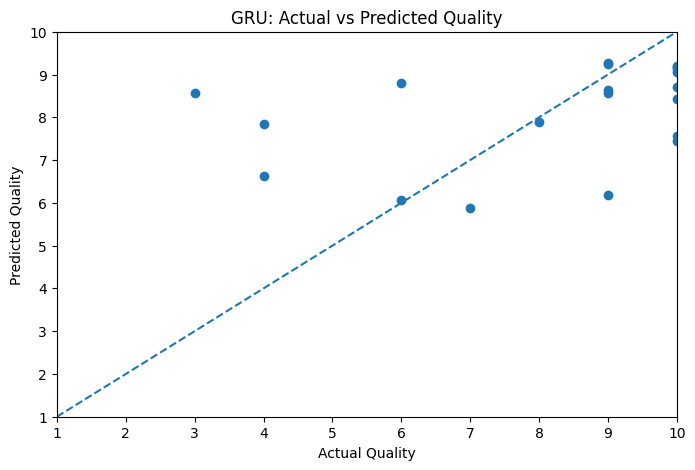

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("GRU: Actual vs Predicted Quality")

plt.plot(
    [1, 10],
    [1, 10],
    linestyle="--"
)

plt.xlim(1, 10)
plt.ylim(1, 10)

plt.show()